# Import and eval functions

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, h5py, gc, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
import concurrent.futures as cf
from pathlib import Path
from torch.utils.data import DataLoader

REPO_ROOT = "./"
proj = Path(REPO_ROOT).resolve()

# allow: import ADCNN.*
sys.path.insert(0, str(proj))

# allow: import utils.*  (where utils == ADCNN/utils)
sys.path.insert(0, str(proj / "ADCNN"))

import ADCNN.inference.postprocess as postprocess
from ADCNN.data.datasets import H5TiledDataset
from ADCNN.inference.predict import load_model, predict_tiles_to_full
from ADCNN.inference.postprocess import postprocess_prediction, postprocess_predictions
import ADCNN.evaluation.detection as evals
import ADCNN.evaluation.threshold_scan as threshold_scan

MODEL_CKPT = "./checkpoints/ckpt_last.pt"

In [2]:
def calculate_model_metrics (catalog, predictions, ground_truth, thr_points=100, stack_fp=None, best_threshold=None):
    catalog = catalog.copy()
    if best_threshold is None:
        threshold_df = threshold_scan.scan_thresholds(catalog=catalog, predictions=predictions, ground_truth=ground_truth, stack_fp=stack_fp, n_points=thr_points)
        threshold_scan.plot_fscore(threshold_df["thr"], pix_f1=threshold_df.get("pix_f1"), pix_f2=threshold_df.get("pix_f2"),
                               obj_f1=threshold_df.get("obj_f1"), obj_f2=threshold_df.get("obj_f2"), title="Pixelwise vs Objectwise F-scores")
        threshold_scan.plot_roc(threshold_scan.compute_roc(threshold_df["pix_tp"], threshold_df["pix_fp"], threshold_df["pix_tn"], threshold_df["pix_fn"]))
        threshold_scan.plot_froc(threshold_scan.compute_froc(thr=threshold_df["thr"], obj_tp=threshold_df["obj_tp"], obj_fp=threshold_df["obj_fp"], obj_fn=threshold_df["obj_fn"], n_images=50),
                             title="FROC (objectwise)")
        best_threshold = threshold_df["thr"][threshold_df["obj_f2"].argmax()]
    _,_,catalog = evals.full_confusion(catalog=catalog, ground_truth= ground_truth,predictions=predictions, stack_fp=stack_fp, threshold=best_threshold, verbose=True)
    _ = evals.combined_confusion_separate(catalog=test_catalog, ground_truth=ground_truth, predictions=predictions, threshold=best_threshold, verbose=True, stack_mask=stack_fp)
    _ = evals.plot_detect_hist(catalog, "PSF_mag", bins=12, title="NN detections vs PSF_mag threshold=" + str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "trail_length", bins=12, title="Detections vs trail length threshold="+ str(round(best_threshold, 3)))
    _ = evals.plot_detect_hist(catalog, "SNR", bins=10, title="Detections vs SNR threshold="+ str(round(best_threshold, 3)), xlim=[0, 10], density=True)
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, title="Model completeness")
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, detected=(~catalog["stack_detection"].values.astype(bool) & catalog["nn_detected"].values.astype(bool)),
                                   title="Model detection but not stack detection")
    plt.show()
    return catalog

def get_stack_metrics (catalog, fp_mask):
    tp = (catalog["stack_detection"]==True).sum()
    fn = (catalog["stack_detection"]==False).sum()
    fp = fp_mask.max(axis=(1, 2)).sum()
    return  {"TP": tp, "FP": fp, "FN": fn, "TN": pd.NA}

# 5 sigma threshold

In [3]:
test_h5 = "./DATA/SNR_5/test.h5"
test_csv = "./DATA/SNR_5/test.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0101, F2 Score: 0.0245
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              116749
Actual Positive                 405                 595



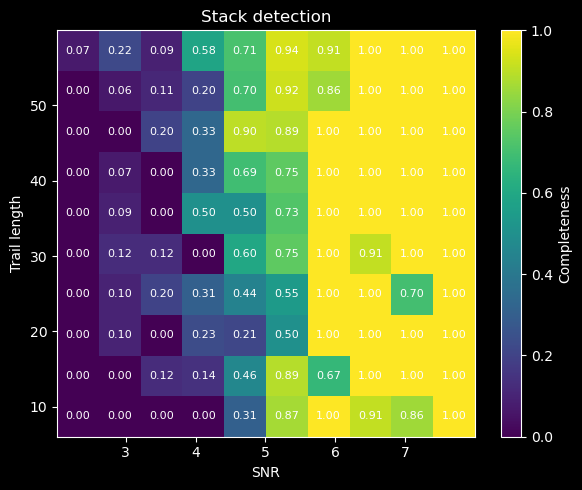

In [4]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [6]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

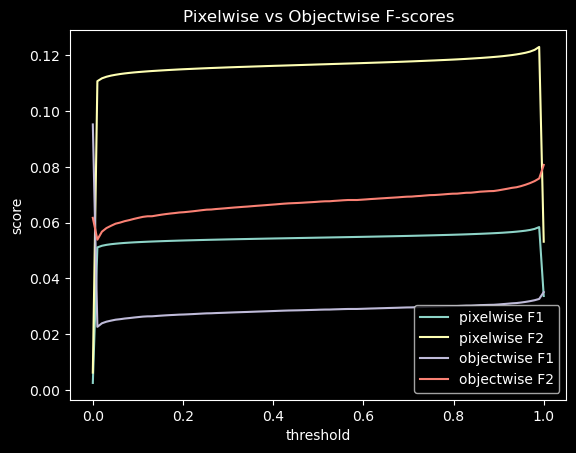

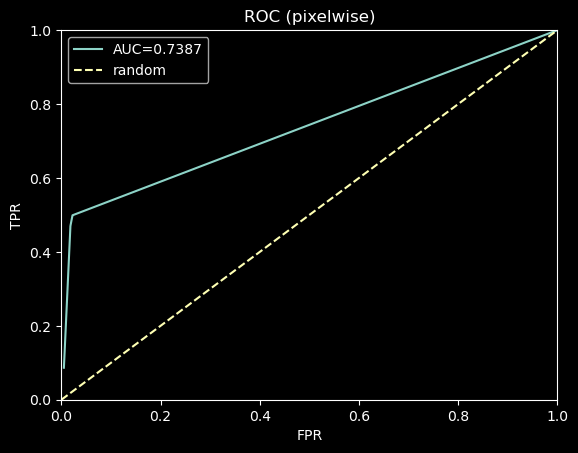

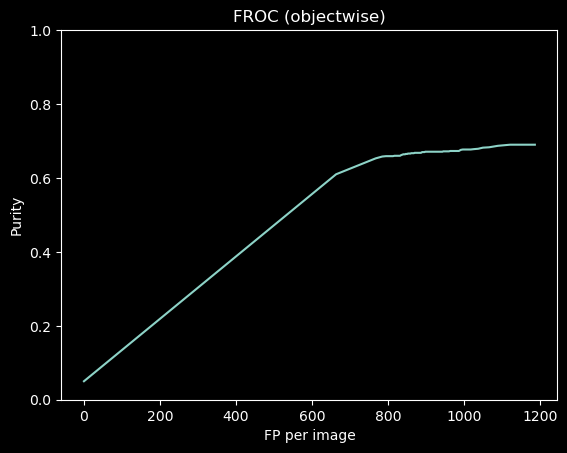

Object-level Confusion Matrix
F1 Score: 0.0356, F2 Score: 0.0819
                 Predicted Negative  Predicted Positive
Actual Negative                   0               32618
Actual Positive                 390                 610

Pixel-level Confusion Matrix
F1 Score: 0.0337, F2 Score: 0.0532
                 Predicted Negative  Predicted Positive
Actual Negative           814874738             4126199
Actual Positive              930154               88109

Combined Object-level Confusion Matrix
F1 Score: 0.0098, F2 Score: 0.0240
                 Predicted Negative  Predicted Positive
Actual Negative                   0              149367
Actual Positive                 261                 739



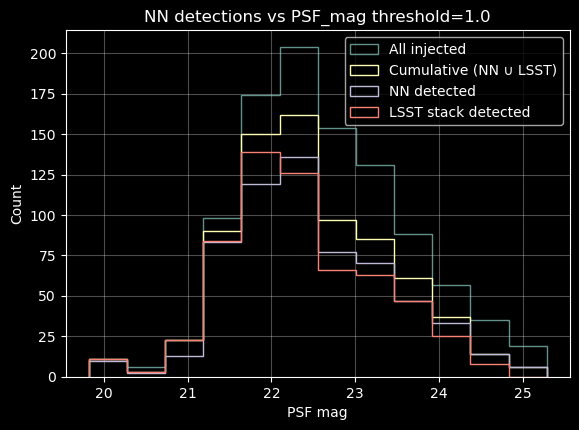

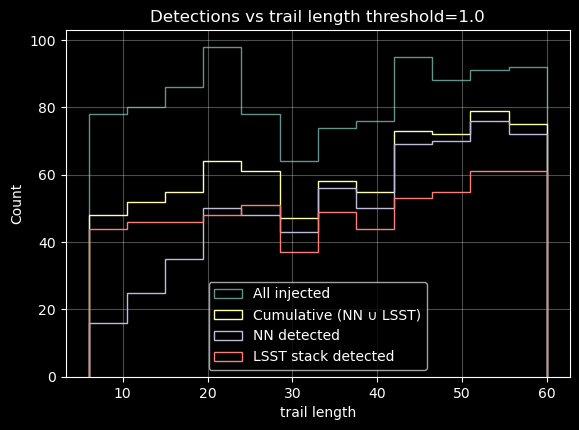

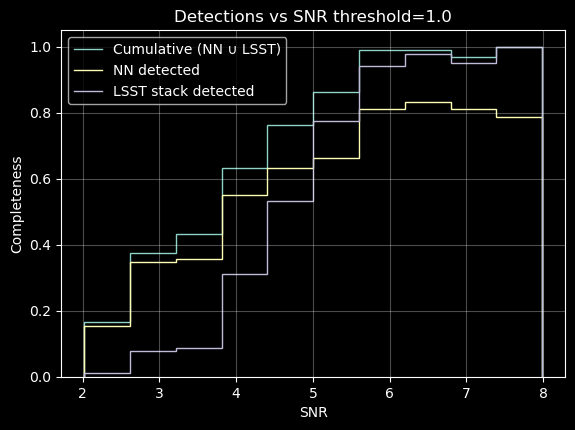

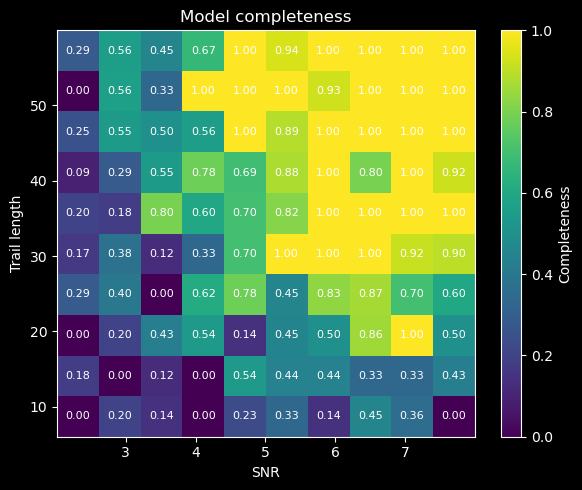

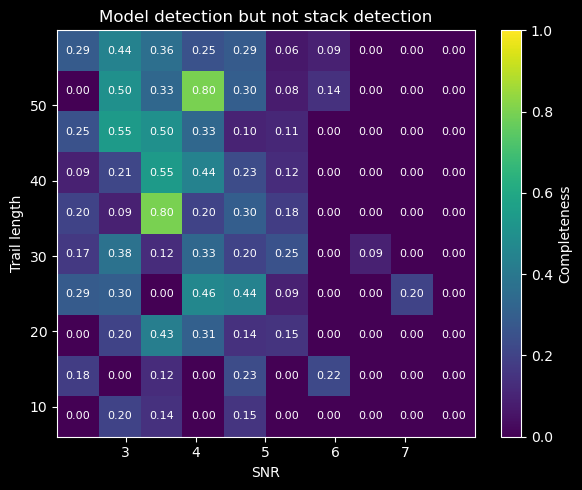

In [7]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0288, F2 Score: 0.0675
                 Predicted Negative  Predicted Positive
Actual Negative                   0               44998
Actual Positive                 329                 671

Pixel-level Confusion Matrix
F1 Score: 0.0546, F2 Score: 0.1168
                 Predicted Negative  Predicted Positive
Actual Negative           802460097            16540840
Actual Positive              525362              492901

Combined Object-level Confusion Matrix
F1 Score: 0.0095, F2 Score: 0.0234
                 Predicted Negative  Predicted Positive
Actual Negative                   0              161747
Actual Positive                 222                 778



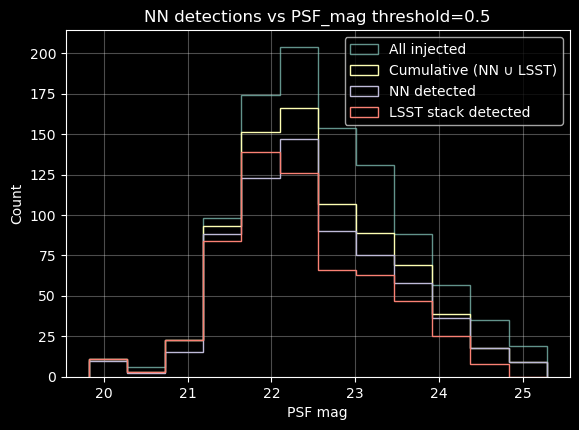

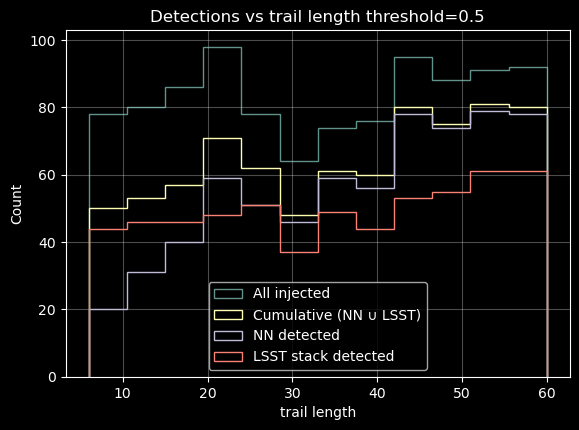

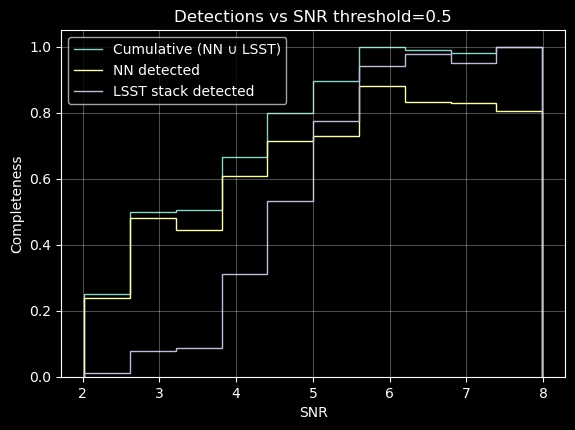

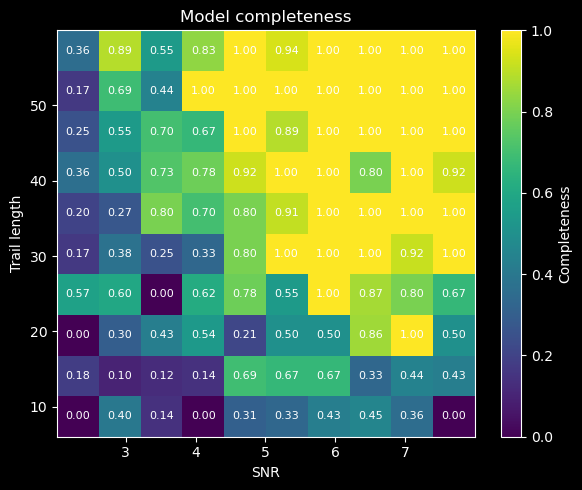

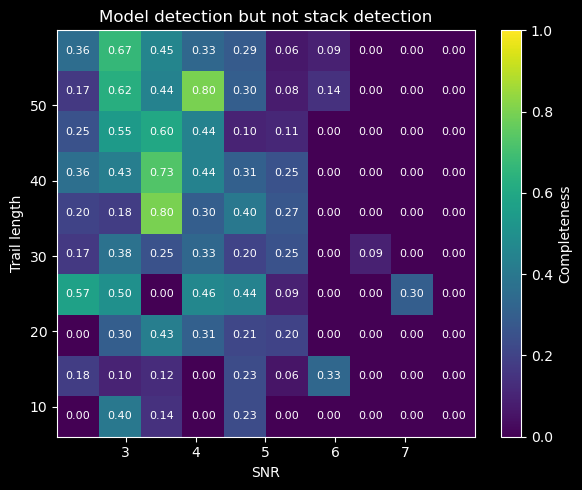

In [8]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0317, F2 Score: 0.0740
                 Predicted Negative  Predicted Positive
Actual Negative                   0               40553
Actual Positive                 331                 669

Pixel-level Confusion Matrix
F1 Score: 0.0536, F2 Score: 0.1151
                 Predicted Negative  Predicted Positive
Actual Negative           801973464            17027473
Actual Positive              521089              497174

Combined Object-level Confusion Matrix
F1 Score: 0.0098, F2 Score: 0.0239
                 Predicted Negative  Predicted Positive
Actual Negative                   0              157302
Actual Positive                 224                 776



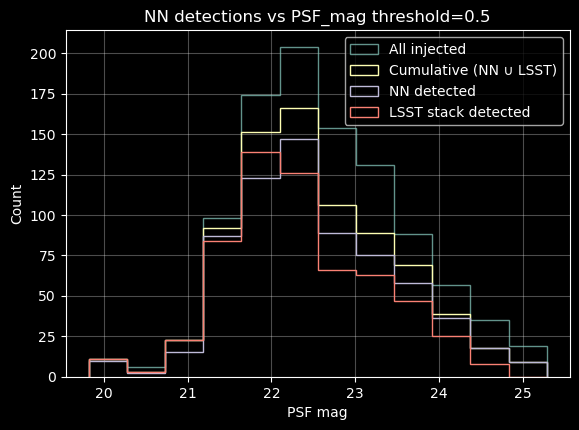

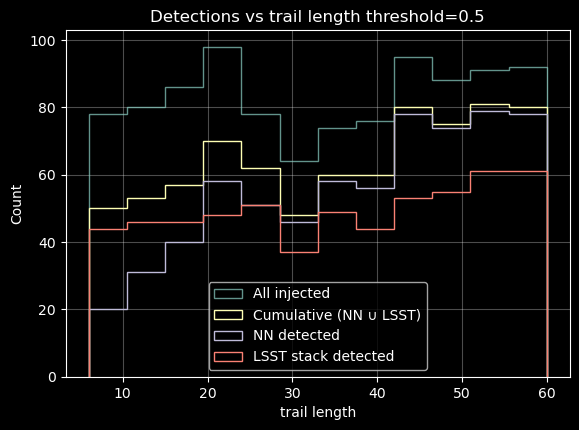

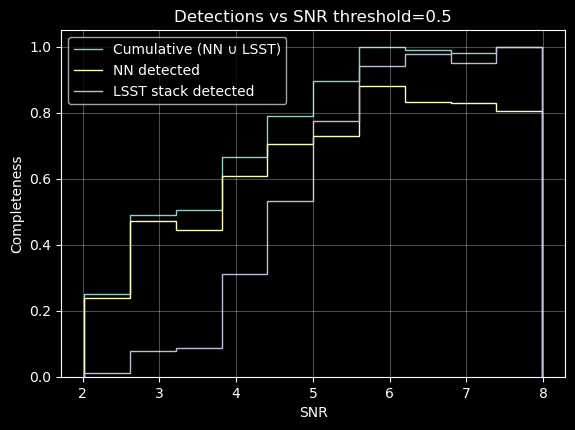

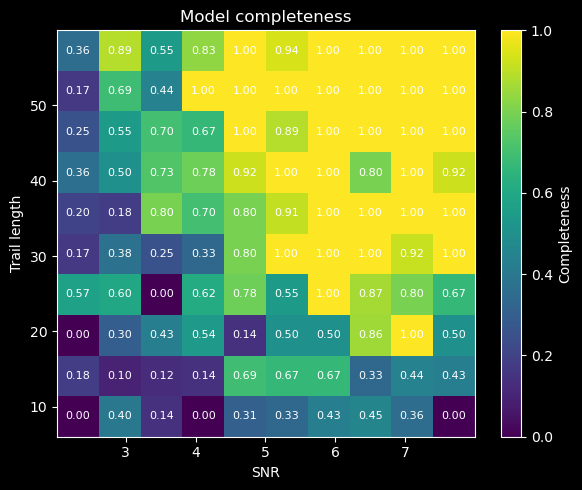

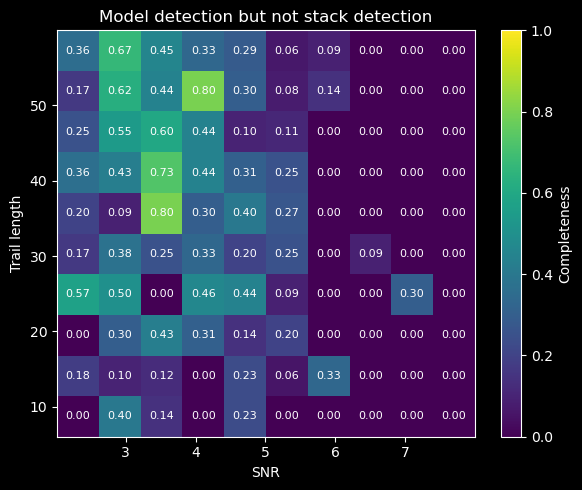

In [9]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 4 sigma threshold

In [10]:
test_h5 = "./DATA/SNR_4/test.h5"
test_csv = "./DATA/SNR_4/test.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0103, F2 Score: 0.0251
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              152934
Actual Positive                 207                 793



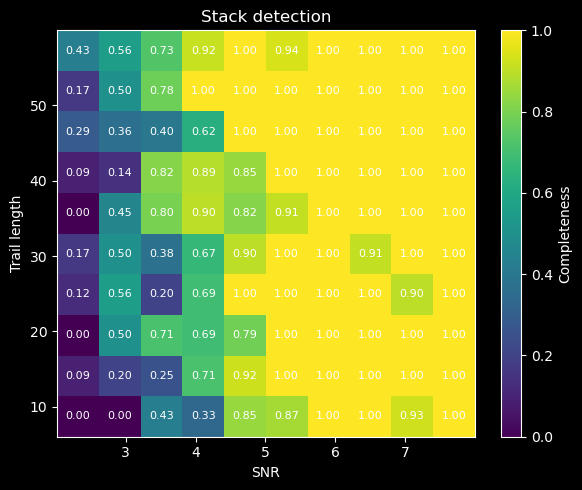

In [11]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [12]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

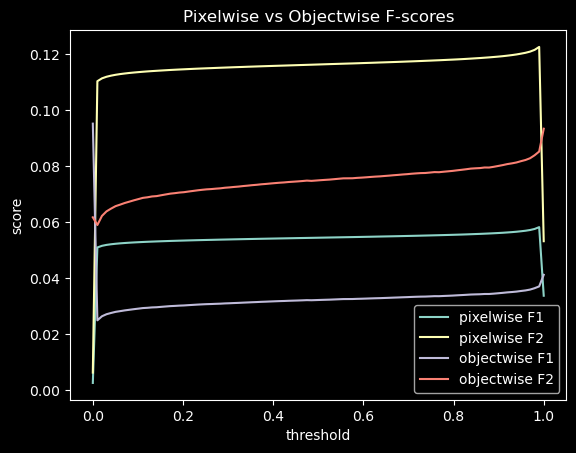

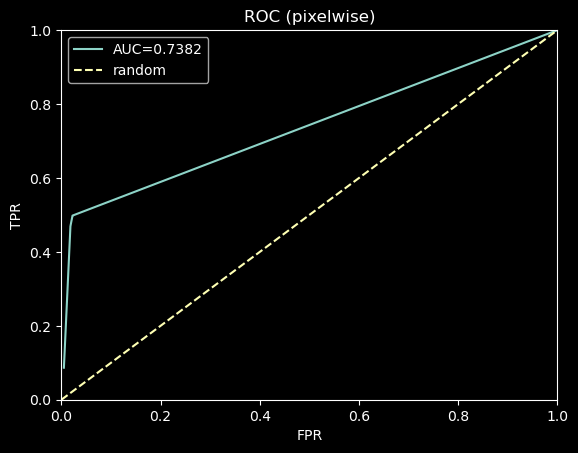

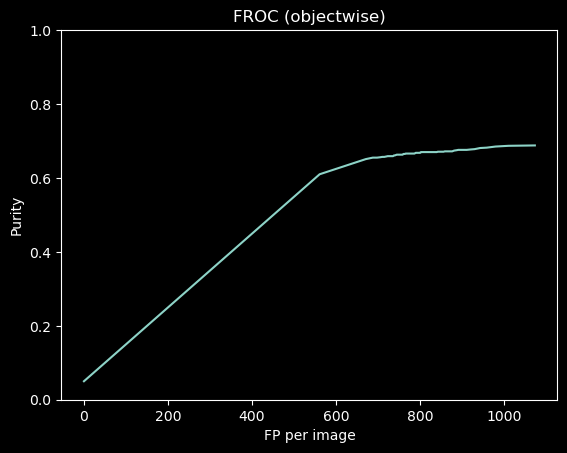

Object-level Confusion Matrix
F1 Score: 0.0420, F2 Score: 0.0951
                 Predicted Negative  Predicted Positive
Actual Negative                   0               27461
Actual Positive                 390                 610

Pixel-level Confusion Matrix
F1 Score: 0.0337, F2 Score: 0.0532
                 Predicted Negative  Predicted Positive
Actual Negative           814876063             4126130
Actual Positive              928933               88074

Combined Object-level Confusion Matrix
F1 Score: 0.0092, F2 Score: 0.0226
                 Predicted Negative  Predicted Positive
Actual Negative                   0              180395
Actual Positive                 163                 837



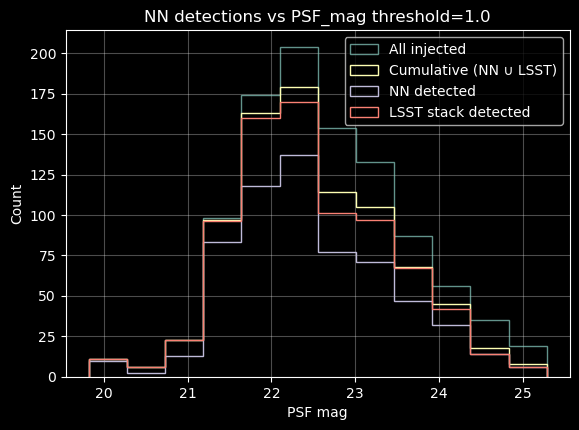

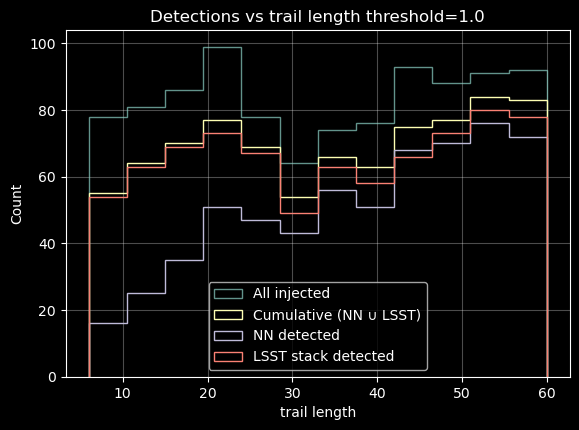

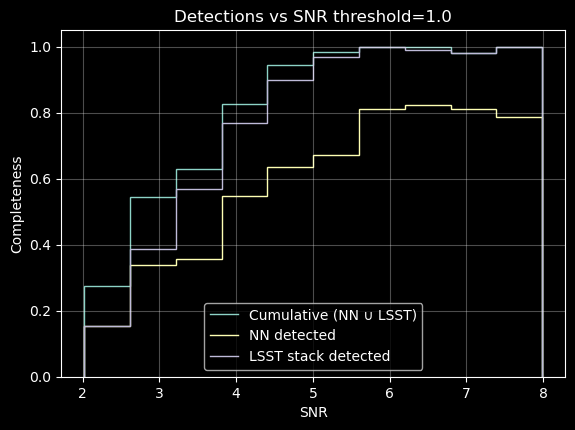

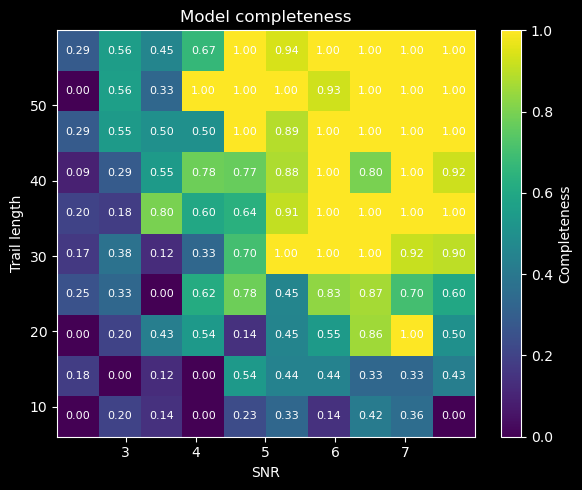

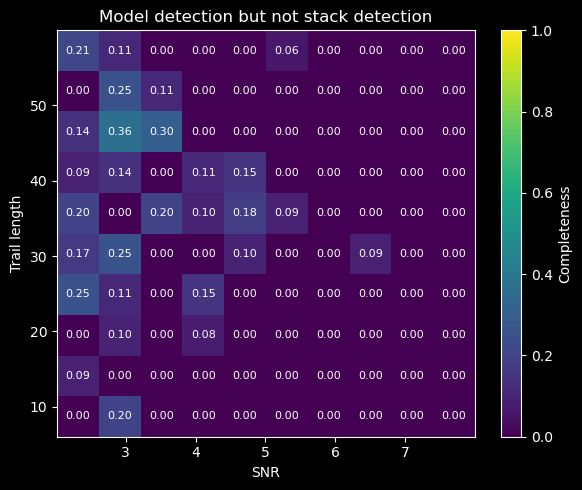

In [13]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 threshold

Object-level Confusion Matrix
F1 Score: 0.0322, F2 Score: 0.0750
                 Predicted Negative  Predicted Positive
Actual Negative                   0               39861
Actual Positive                 332                 668

Pixel-level Confusion Matrix
F1 Score: 0.0544, F2 Score: 0.1164
                 Predicted Negative  Predicted Positive
Actual Negative           802449768            16552425
Actual Positive              525544              491463

Combined Object-level Confusion Matrix
F1 Score: 0.0088, F2 Score: 0.0217
                 Predicted Negative  Predicted Positive
Actual Negative                   0              192795
Actual Positive                 143                 857



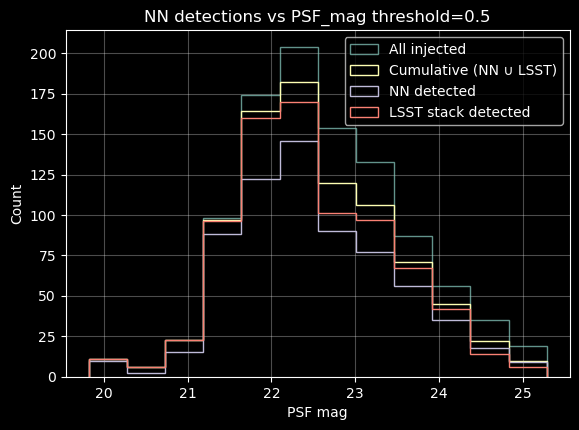

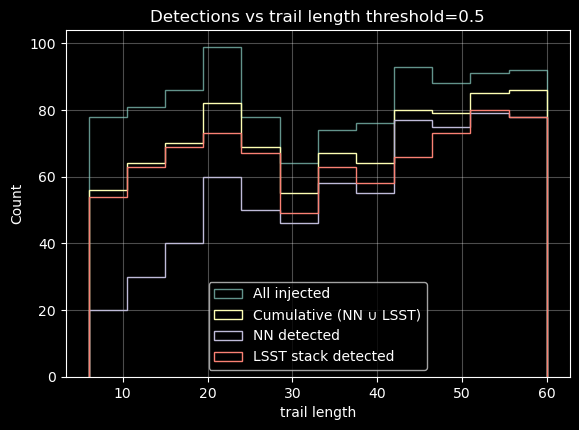

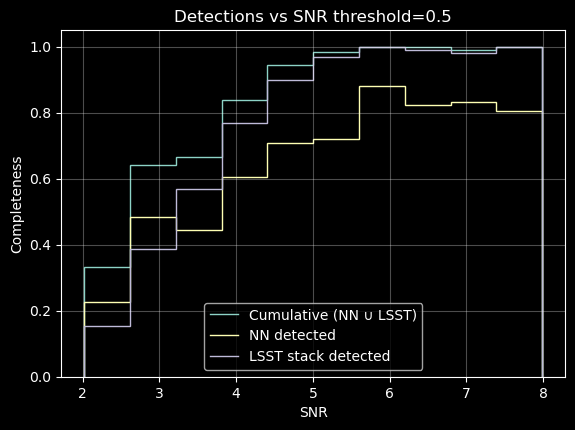

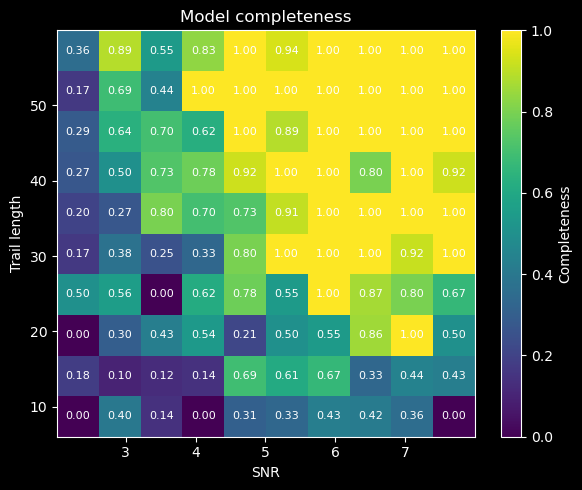

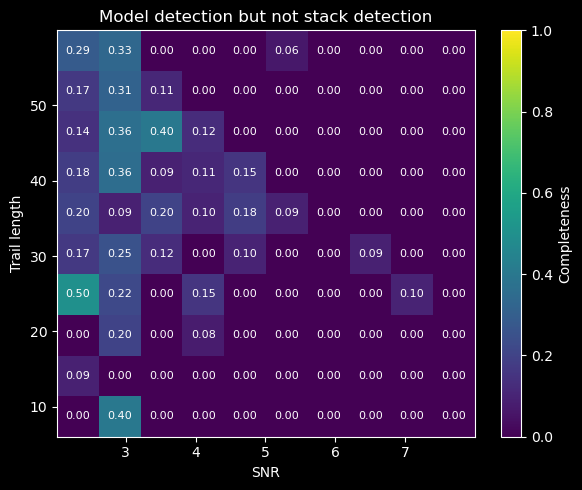

In [14]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0359, F2 Score: 0.0831
                 Predicted Negative  Predicted Positive
Actual Negative                   0               35516
Actual Positive                 332                 668

Pixel-level Confusion Matrix
F1 Score: 0.0534, F2 Score: 0.1147
                 Predicted Negative  Predicted Positive
Actual Negative           801963145            17039048
Actual Positive              521358              495649

Combined Object-level Confusion Matrix
F1 Score: 0.0090, F2 Score: 0.0222
                 Predicted Negative  Predicted Positive
Actual Negative                   0              188450
Actual Positive                 143                 857



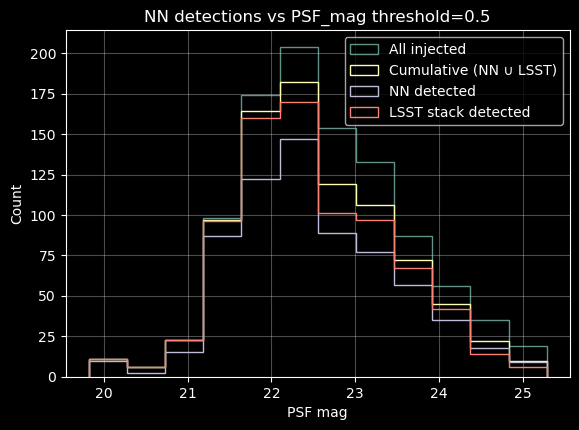

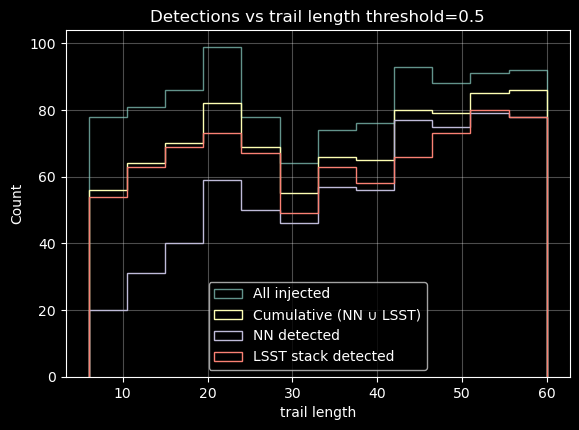

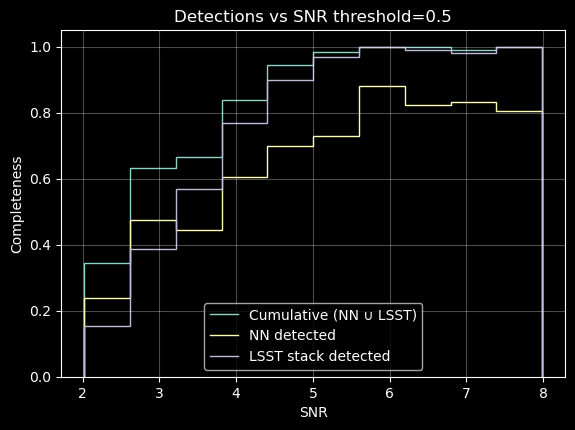

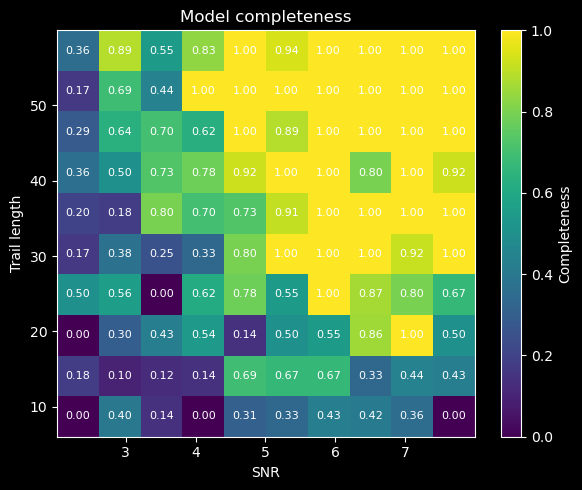

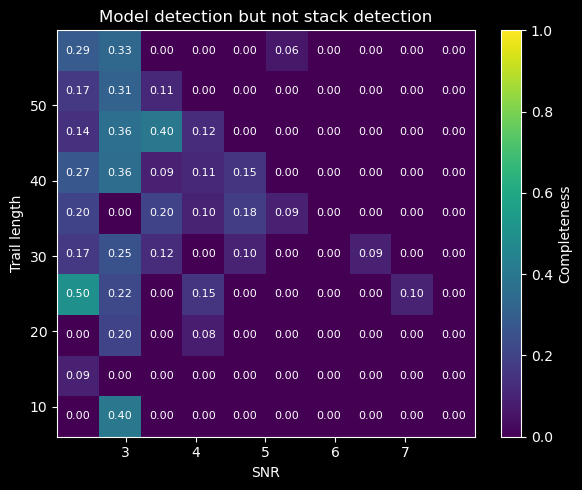

In [15]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# 3 sigma threshold

In [16]:
test_h5 = "./DATA/SNR_3/test.h5"
test_csv = "./DATA/SNR_3/test.csv"

ds_te = H5TiledDataset(test_h5,  tile=128, k_sigma=5.0)

test_loader = DataLoader(
    ds_te,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Test tiles:", len(ds_te))

Test tiles: 51200


## LSST stack

Object-wise Confusion Matrix
F1 Score: 0.0069, F2 Score: 0.0170
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              268856
Actual Positive                  70                 930



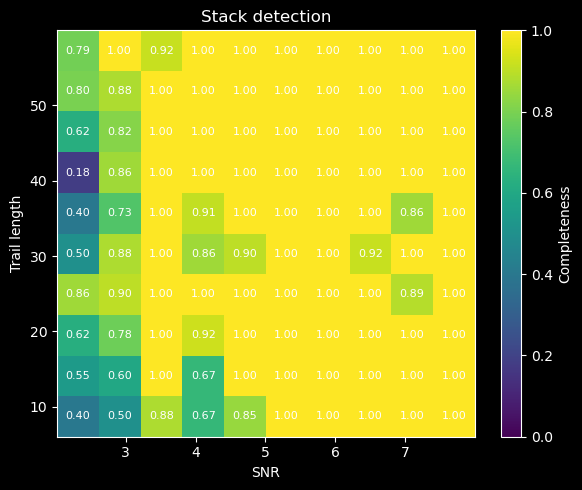

In [17]:
evals.print_confusion_matrix(get_stack_metrics (test_catalog, stack_fp), title="Object-wise Confusion Matrix")
_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")

## Model

In [18]:
model = load_model(MODEL_CKPT)
p = predict_tiles_to_full(test_h5, test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
print("Predictions shape:", p.shape)

Loaded model from: ./checkpoints/ckpt_last.pt
Predictions shape: (50, 4004, 4096)


### Best threshold

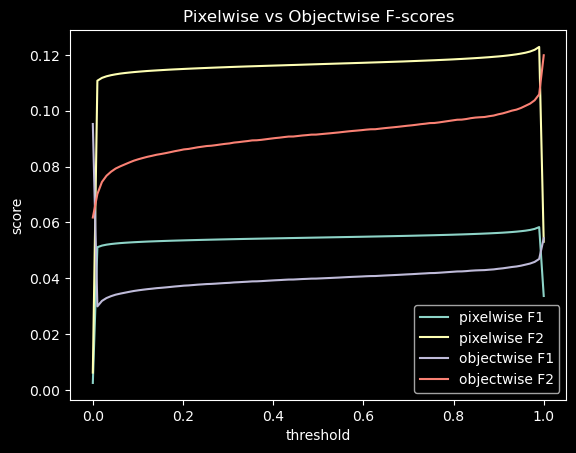

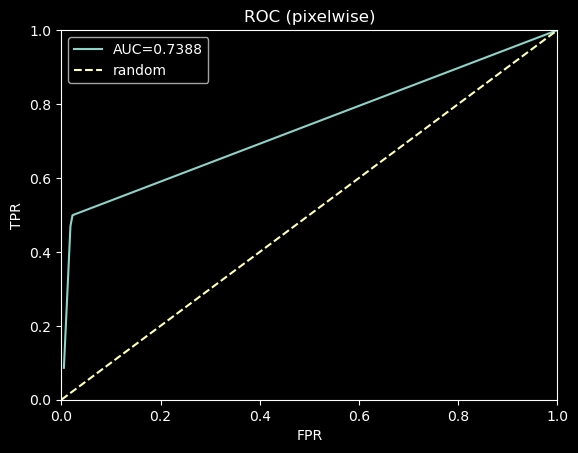

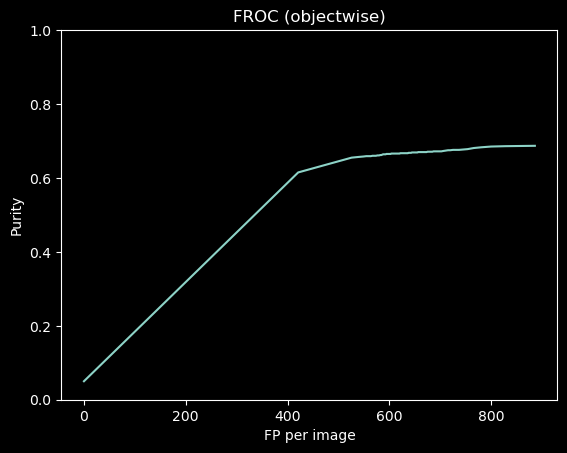

Object-level Confusion Matrix
F1 Score: 0.0557, F2 Score: 0.1226
                 Predicted Negative  Predicted Positive
Actual Negative                   0               20459
Actual Positive                 385                 615

Pixel-level Confusion Matrix
F1 Score: 0.0336, F2 Score: 0.0531
                 Predicted Negative  Predicted Positive
Actual Negative           814874013             4126498
Actual Positive              930721               87968

Combined Object-level Confusion Matrix
F1 Score: 0.0065, F2 Score: 0.0160
                 Predicted Negative  Predicted Positive
Actual Negative                   0              289315
Actual Positive                  59                 941



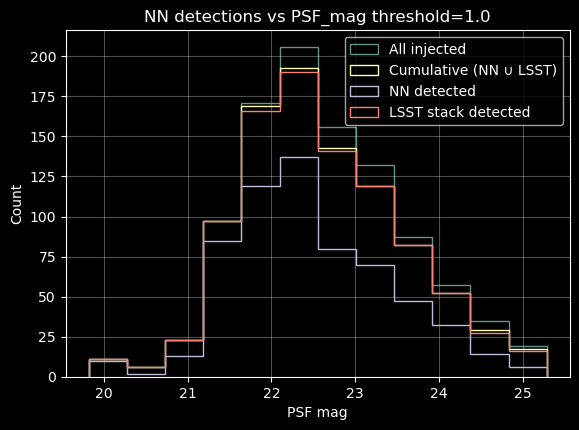

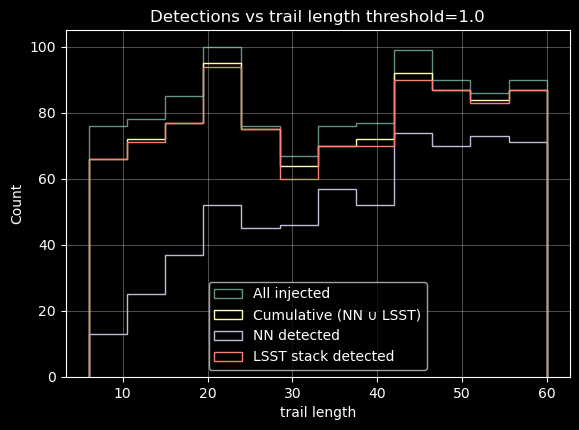

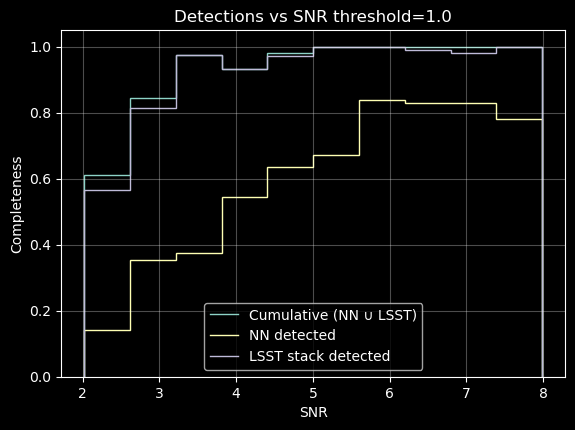

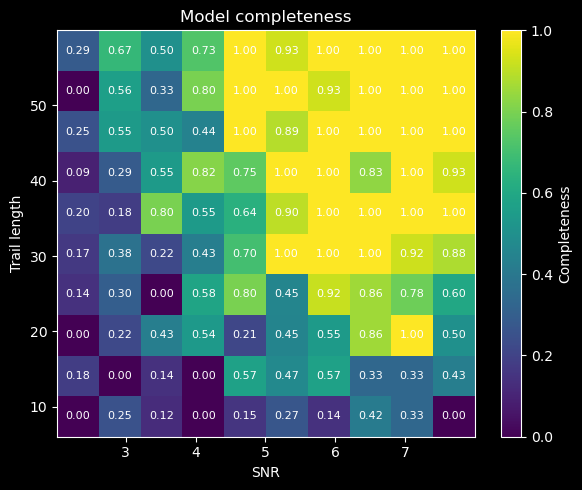

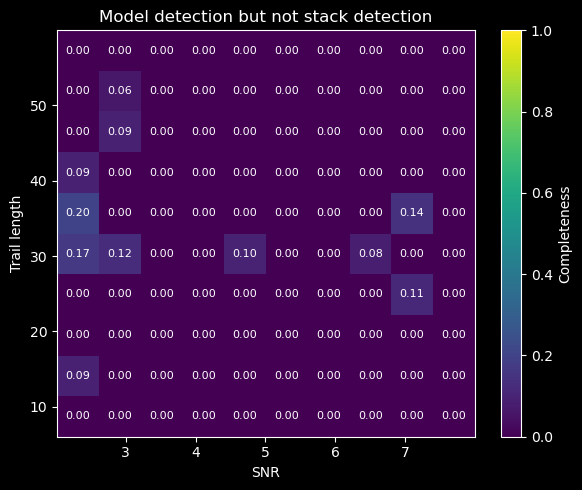

In [19]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp)

### 0.5 Threshold

Object-level Confusion Matrix
F1 Score: 0.0399, F2 Score: 0.0916
                 Predicted Negative  Predicted Positive
Actual Negative                   0               31751
Actual Positive                 333                 667

Pixel-level Confusion Matrix
F1 Score: 0.0546, F2 Score: 0.1167
                 Predicted Negative  Predicted Positive
Actual Negative           802439864            16560647
Actual Positive              525708              492981

Combined Object-level Confusion Matrix
F1 Score: 0.0063, F2 Score: 0.0155
                 Predicted Negative  Predicted Positive
Actual Negative                   0              300607
Actual Positive                  51                 949



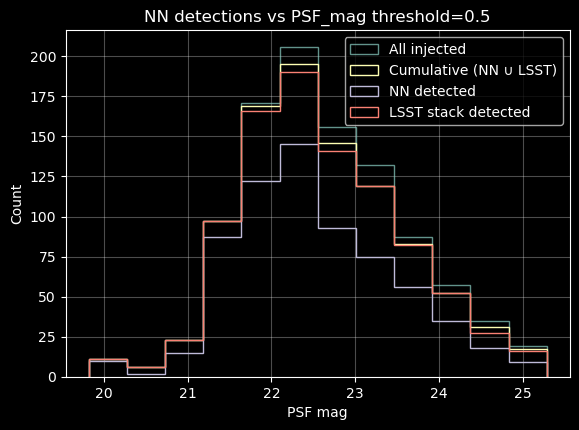

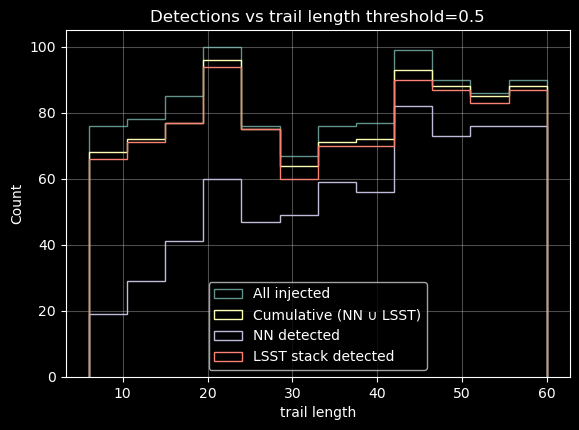

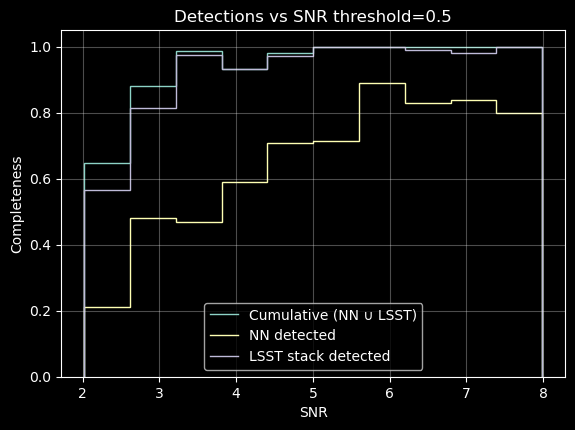

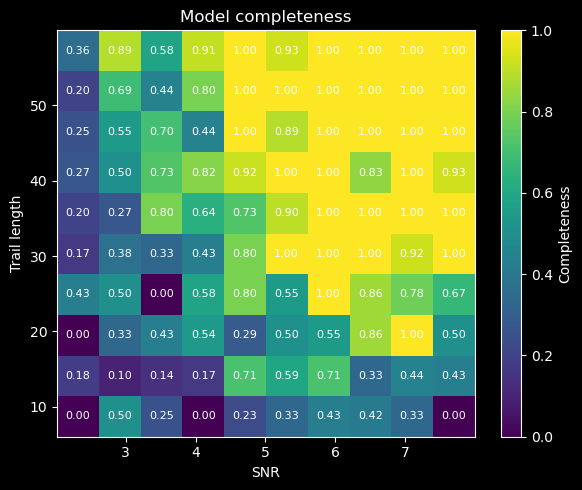

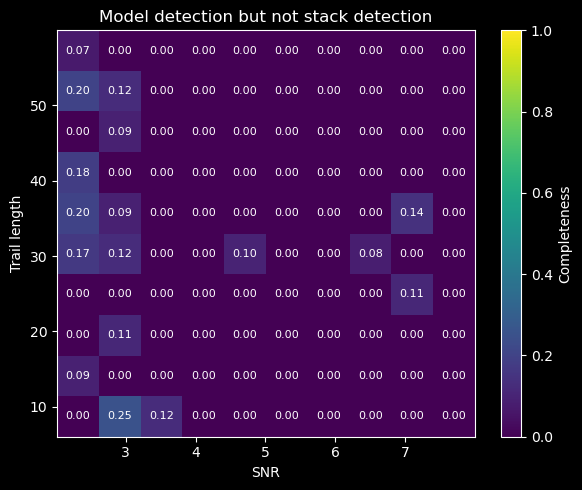

In [20]:
__ = calculate_model_metrics(test_catalog, p, gt_test, stack_fp=stack_fp, best_threshold=0.5)

### Two stage classifier

Object-level Confusion Matrix
F1 Score: 0.0455, F2 Score: 0.1031
                 Predicted Negative  Predicted Positive
Actual Negative                   0               27680
Actual Positive                 333                 667

Pixel-level Confusion Matrix
F1 Score: 0.0536, F2 Score: 0.1150
                 Predicted Negative  Predicted Positive
Actual Negative           801952563            17047948
Actual Positive              521419              497270

Combined Object-level Confusion Matrix
F1 Score: 0.0064, F2 Score: 0.0157
                 Predicted Negative  Predicted Positive
Actual Negative                   0              296536
Actual Positive                  51                 949



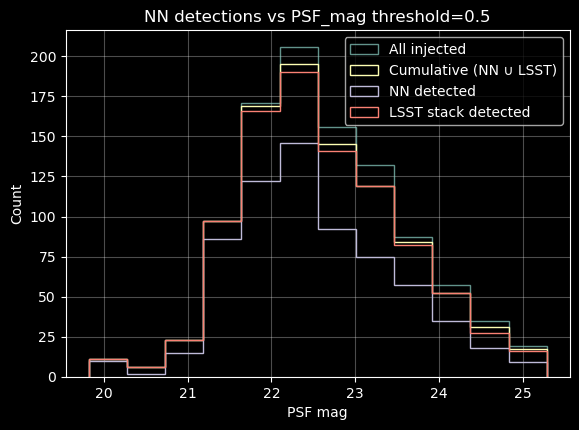

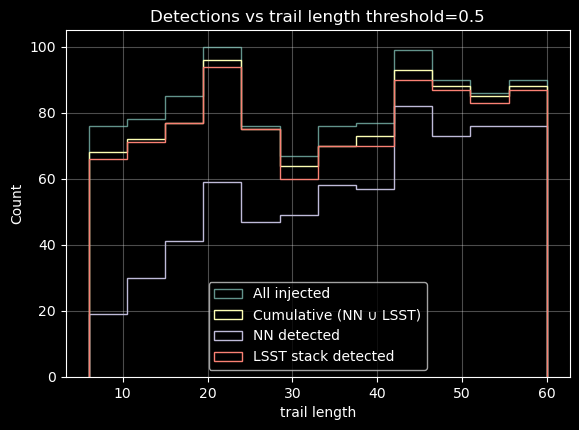

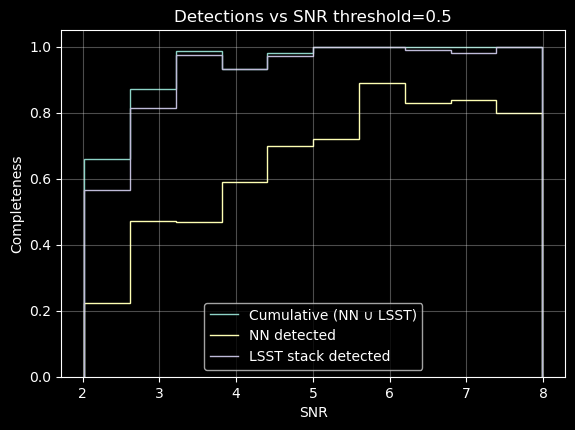

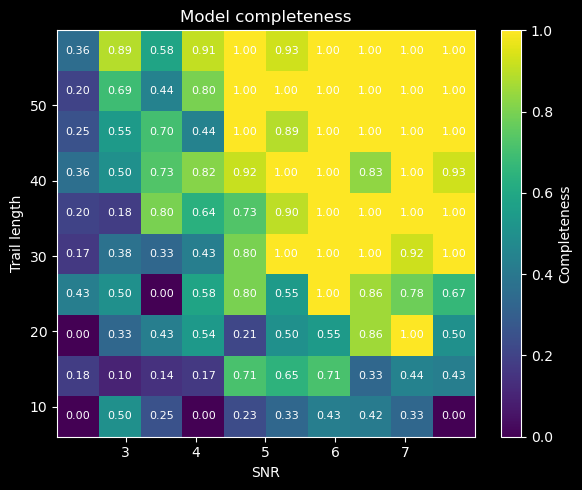

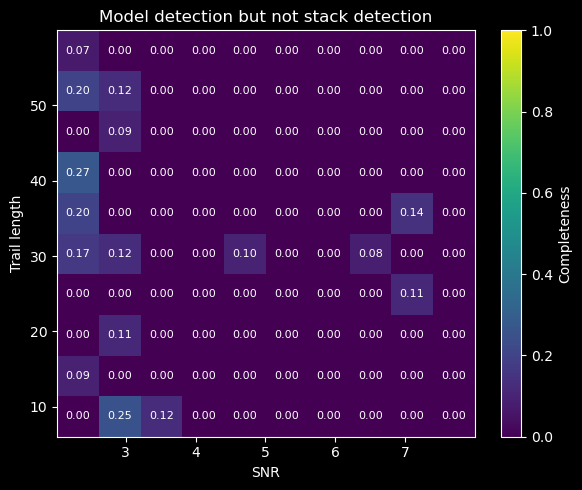

In [21]:
masks, detections = postprocess_predictions(predictions=p, return_label_mask=True)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, best_threshold=0.5)

# Combined

In [24]:
def plot_detect_hist(catalogs, field, labels = None, bins=12, title=None, density=False, xlim=None):
    legend = True
    if labels is None:
        labels = ["" for i in range(len(catalogs))]
        legend = False
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    for ll, cat in enumerate(catalogs):
        detected = cat[cat["stack_detection"]]
        vals = cat[field].to_numpy(); vals = vals[np.isfinite(vals)]
        if xlim is not None:
            vals = vals[(vals>=xlim[0]) & (vals<=xlim[1])]
        edges = np.histogram_bin_edges(vals, bins=bins)
        if not density:
            ax.hist(detected[field], bins=edges, histtype="step", label=labels[ll])
            ax.set_xlabel(field.replace("_"," ")); ax.set_ylabel("Count")
        else:
            all_i = np.histogram(cat[field],     bins=edges)[0]
            stk_i = np.histogram(detected[field], bins=edges)[0]
            bin_widths = np.diff(edges)
            ax.stairs(stk_i/all_i, edges, label=labels[ll])
            ax.set_xlabel(field.replace("_"," ")); ax.set_ylabel("Completeness")
    if title: ax.set_title(title)
    if legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax

In [26]:
test_catalog5 = pd.read_csv("./DATA/SNR_5/test.csv")
with h5py.File("./DATA/SNR_5/test.h5", "r") as _f:
    gt_test5 = _f["masks"][:].astype(np.uint8)
    stack_fp5 = _f["real_labels"][:].astype(np.uint16)
test_loader = DataLoader(
    H5TiledDataset("./DATA/SNR_5/test.h5",  tile=128, k_sigma=5.0),
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=None,
)

model = load_model(MODEL_CKPT)
p = predict_tiles_to_full("./DATA/SNR_5/test.h5", test_loader, model, tile=128)
model.to('cpu')
gc.collect()
torch.cuda.empty_cache()
p, _ = postprocess_predictions(predictions=p, return_label_mask=True)
_,_, test_catalog5_nn = evals.full_confusion(catalog=test_catalog5, ground_truth= gt_test5,predictions=p, stack_fp=stack_fp5, threshold=0.5, verbose=False)


test_catalog4 = pd.read_csv("./DATA/SNR_4/test.csv")
with h5py.File("./DATA/SNR_4/test.h5", "r") as _f:
    stack_fp4 = _f["real_labels"][:].astype(np.uint16)

test_catalog3 = pd.read_csv("./DATA/SNR_3/test.csv")
with h5py.File("./DATA/SNR_3/test.h5", "r") as _f:
    stack_fp3 = _f["real_labels"][:].astype(np.uint16)

Loaded model from: ./checkpoints/ckpt_last.pt


(<Figure size 650x450 with 1 Axes>,
 <Axes: xlabel='trail length', ylabel='Completeness'>)

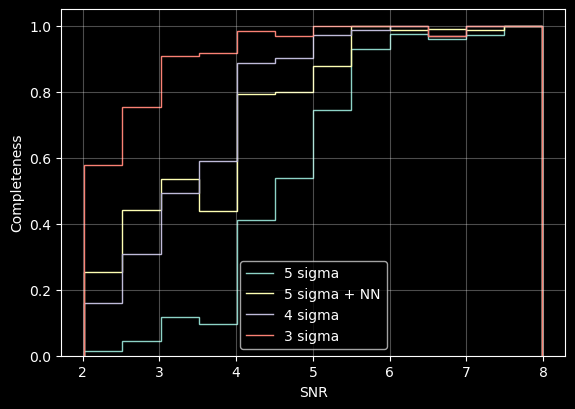

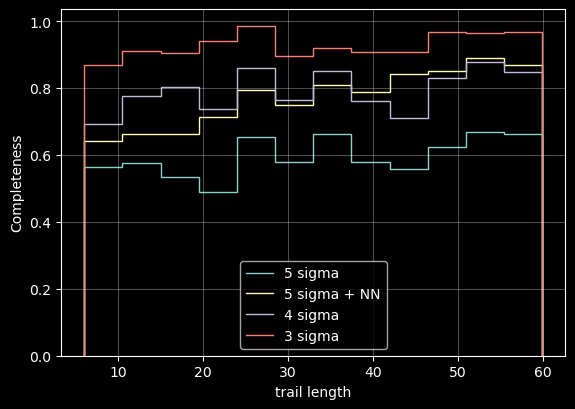

In [37]:
test_catalog5_nn["stack_detection_backup"] = test_catalog5_nn["stack_detection"]
test_catalog5_nn["stack_detection"] = test_catalog5_nn["stack_detection"] | test_catalog5_nn["nn_detected"]
plot_detect_hist([test_catalog5, test_catalog5_nn, test_catalog4, test_catalog3], "SNR", labels=["5 sigma", "5 sigma + NN",  "4 sigma", "3 sigma"], density=True)
plot_detect_hist([test_catalog5, test_catalog5_nn, test_catalog4, test_catalog3], "trail_length", labels=["5 sigma", "5 sigma + NN",  "4 sigma", "3 sigma"], density=True)

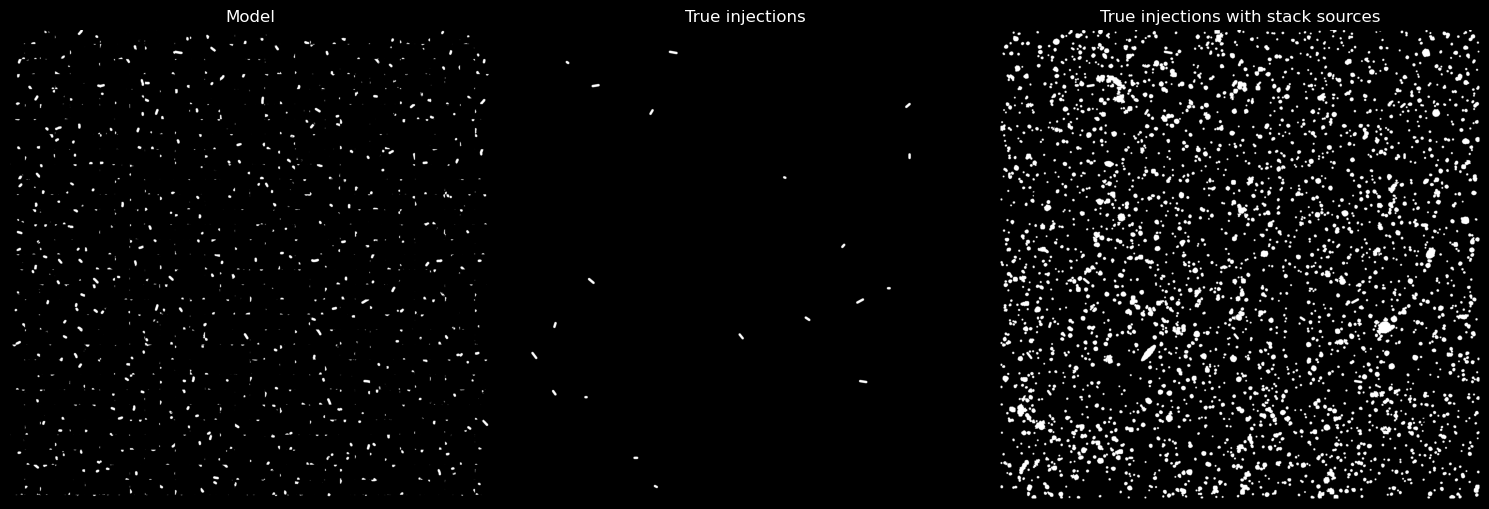

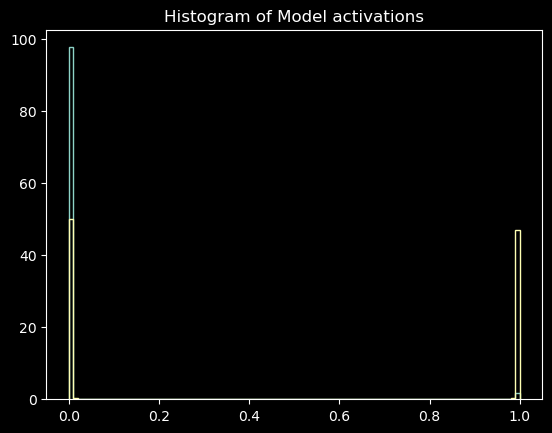

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(p[0], cmap='gray', vmin=0, vmax=1)
ax[0].axis('off')
ax[0].set_title("Model")
ax[1].imshow((gt_test[0]), cmap='gray', vmin=0, vmax=1)
ax[1].axis('off')
ax[1].set_title("True injections")
ax[2].imshow((gt_test[0] | (stack_fp[0] > 0.5)), cmap='gray', vmin=0, vmax=1)
ax[2].axis('off')
ax[2].set_title("True injections with stack sources")
fig.tight_layout()
plt.show()
plt.hist(p[gt_test<0.5].flatten(), density=True, bins=100, histtype='step')
plt.hist(p[gt_test>0.5].flatten(), density=True, bins=100, histtype='step')
plt.title("Histogram of Model activations")
plt.show()